In [1]:
# import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# - import database / data
# Sql Query Write in three cots '''

# Build Connection
conn = sqlite3.connect("E:\Data Analysis portfolio project\customer_churn.db")

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';

"""

tables = pd.read_sql(sql_query, conn)

# Create Dataframe for each Table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close Connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print table names and column names

# Build Connection
conn = sqlite3.connect("E:\Data Analysis portfolio project\customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")

    #Get Column Information
    columns_query = f"PRAGMA table_info({table_name});"     # "PRAGMA" this is a special command to get table information.
    columns = pd.read_sql(columns_query, conn)         # Read With Pandas.
    print("Columns:")
    print(columns['name'].tolist())

# Close Connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
# 2 - Data Cleaning
# Shows the first 5 rows.
df_db_customer.head()   #head() is a Pandas DataFrame method used to display the first few rows of a DataFrame.

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
# Shows the last 5 rows.
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
#info() is used to see the complete information about a DataFrame, such as rows, columns, data types, and missing values.

df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# Shows summary statistics (count, mean, min, max, etc.).

df_db_customer.describe()

,customerid,name,country,state,gender,dob,interests,pincode
count,21,21,18,21,21,21,4,0
unique,21,21,2,9,4,21,4,0
top,0002-ORFBO,keshav,India,Delhi,Female,1982-04-12 00:00:00,travel,NaN
freq,1,1,17,4,9,1,1,NaN


In [8]:
# a. Rename col - name
# b. drop columns - interests & Pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [9]:
# a . Rename Columns -  name
# For change the column name
df_db_customer.rename(columns = {'name': 'customer_name'},inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [10]:
# b. drop columns - interest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:],axis = 1)   # 1st way to drop columns

df_db_customer.drop(df_db_customer.columns[6:],axis = 1)     # 2nd way to drop columns

#df_db_customer.drop(columns=['interests','pincode'])    # 3rd way to drop columns

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [11]:
# c. Change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
# d. data standardization -  gender

#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [13]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [14]:
# e - Fix missing Values - Country

df_db_customer[df_db_customer['country'].isna()]   # 'isna' means find null values

#'True' Means value are Null and 'False' means Values are Non-Null

,customerid,customer_name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [15]:
# country & state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [16]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [22]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [23]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [24]:
# Feature Engineering & Data Analysis

np.where(df_db_subscription['cancellation_date'].notna(),1,0)

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [25]:
# Create a new col using existing col - 'Churn Flag'
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [26]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [27]:
# First Fix Support table Duplicates then Merge
df = (df_db_subscription
             .merge(df_db_customer, on = 'customerid', how = 'left')
             .merge(df_db_support, on = 'customerid', how = 'left'))

In [28]:
df_db_subscription.shape      # output : 21 Rows & 12 Columns To check Data

(21, 12)

In [29]:
df.shape # ourput : 23 Rows & 20 Columns

(23, 22)

In [30]:
df_db_subscription['customerid'].nunique()

21

In [31]:
df_db_customer['customerid'].nunique()

21

In [32]:
df_db_support['customerid'].nunique()

7

In [33]:
df_db_support['customerid'].size

9

In [34]:
# Using Group by to count

df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [35]:
# remove Duplicates Values
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [36]:
df_db_support['customerid'].size

7

In [37]:
# Merge DF
df = (df_db_subscription
             .merge(df_db_customer, on = 'customerid', how = 'left')
             .merge(df_db_support, on = 'customerid', how = 'left'))

In [38]:
df.shape

(21, 23)

In [39]:
#Converted to Excel 'csv' File
df.to_csv('E:\Data Analysis portfolio project\customer_churn.csv', index = False)

In [40]:
# Data Analysis

#1. Churn Rate
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='object')

In [41]:
churn_rate = df['churn_flag'].mean()*100
print("churn Rate =", round(churn_rate,2), "%")

churn Rate = 28.57 %


In [42]:
# Retension Rate

retention_rate = 100 - churn_rate
print("Retension Rate = ", round(retention_rate,2), "%")

Retension Rate =  71.43 %


In [43]:
# Churn by plan Type

df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [44]:
# Converted in Percentage - 'mul' multiply by 100 & round means Decimal
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [45]:
# 4 ARPU - Average Revenue Per User
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [46]:
# 5 -  Average customer Tenure
# Count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today()      # For Today date

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)
    

Avg Tenure (Days) =  1492 0


In [50]:
#6 Revenue at Risk  - Revenue lost from churned Users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk (₹ lakh) =", revenue_at_risk)

Revenue at Risk (₹ lakh) = 73.94


In [51]:
#7 Escalation rate

escalation_rate = (df['escalations']== 'Y').mean()*100
print("Esclation Rate =", round(escalation_rate, 2), "%")

Esclation Rate = 19.05 %


In [56]:
#8 - Avg Complaint Per User
avg_complaints = df['complaint_count'].sum()/ df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [83]:
#11
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [84]:
#11 Churn risk -  create a column usign existing col.

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 50)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [87]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [ ]:
# Visualization using Matplotlib

In [88]:
df_visual = df.copy()

In [89]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'esacalations', 'churn_risk'],
      dtype='object')

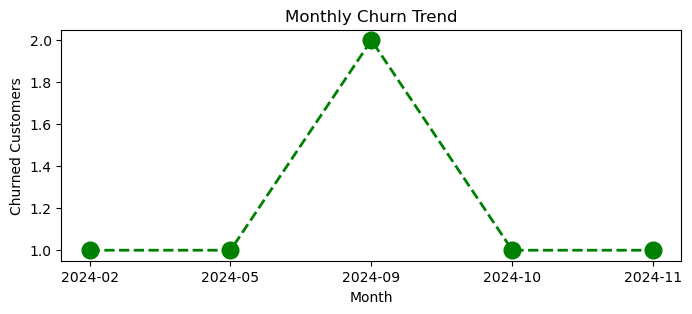

In [99]:
# Monthly Churn Trend ( Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

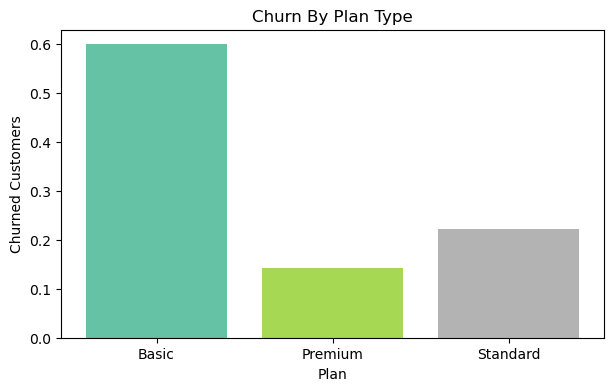

In [112]:
# Churn By Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors  = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))    # Choose Random Colors

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn By Plan Type')
plt.xlabel('Plan')
plt.ylabel('Churned Customers')
plt.show()

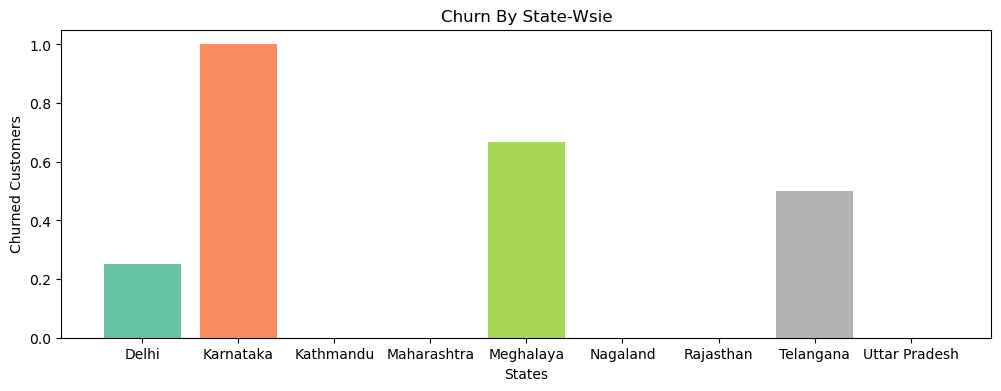

In [115]:
# Churn By Sate
churn_state = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors  = plt.cm.Set2(np.linspace(0,1,len(churn_state)))    # Choose Random Colors

plt.figure(figsize=(12,4))

plt.bar(churn_state.index, churn_state.values, color = colors)

plt.title('Churn By State-Wsie')
plt.xlabel('States')
plt.ylabel('Churned Customers')
plt.show()

In [ ]:
# Visualization Using Seaborn

In [123]:
import warnings
warnings.filterwarnings("ignore")

In [126]:
# encoding -  convert str to numeric so that we can find corr between features.
# incorrect method of enoding - as numbers are not assigned based on priority.

#df_visual.columns

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

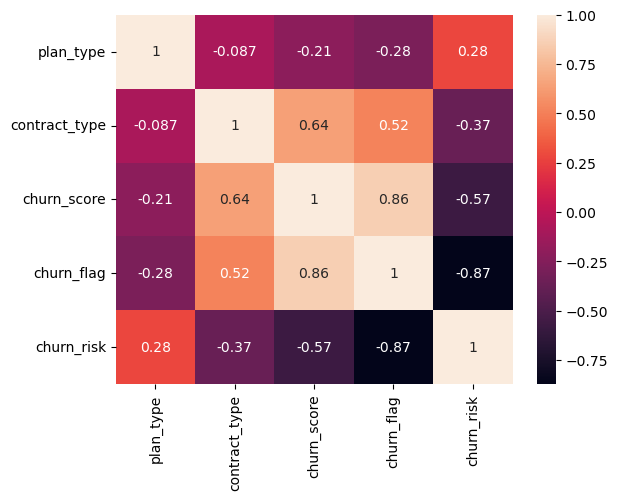

In [127]:
# Heatmap (correlations matrix)

sns.heatmap(df_encoded.corr(), annot = True)

In [128]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [130]:
# correct method of enoding - based on priority.

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low','med','high']
}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered = True).codes

In [131]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk
0,1,1,12,0,0
1,2,1,91,1,2
2,0,0,34,0,0
3,2,1,8,0,0
4,1,0,88,1,2


<Axes: >

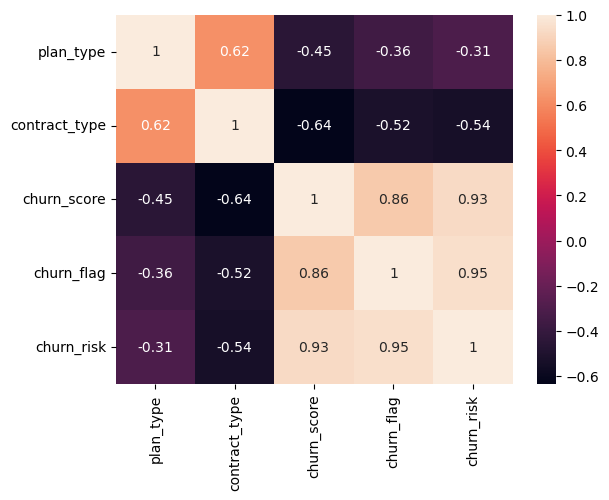

In [132]:
# Heatmap (correlations matrix)

sns.heatmap(df_encoded.corr(), annot = True)

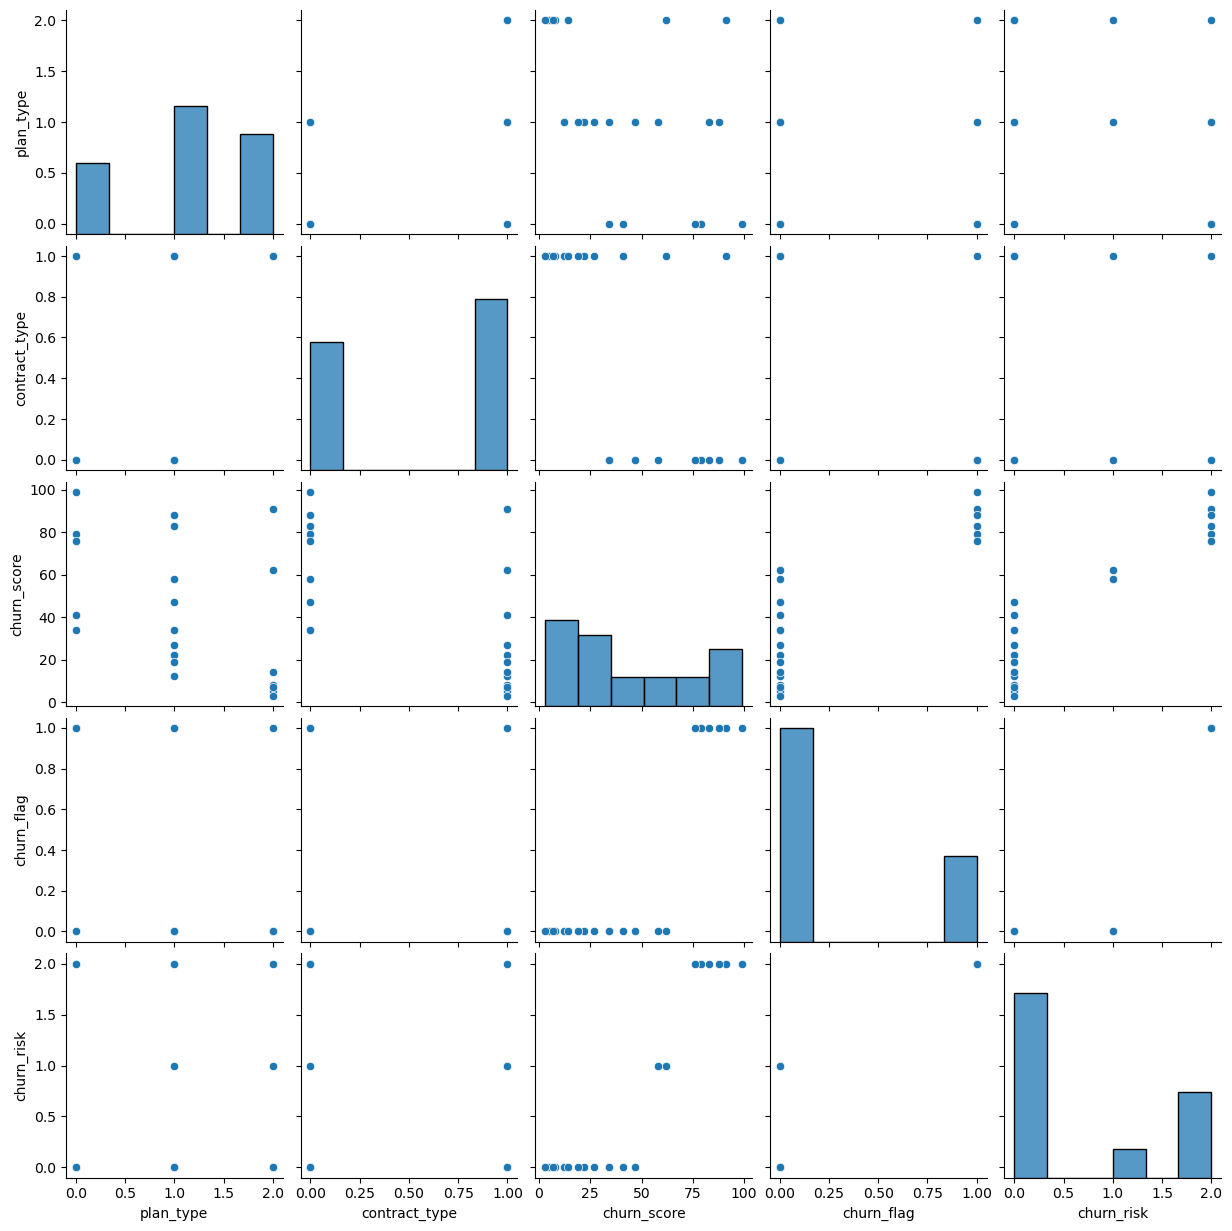

In [133]:
# Pairplot

sns.pairplot(df_encoded)

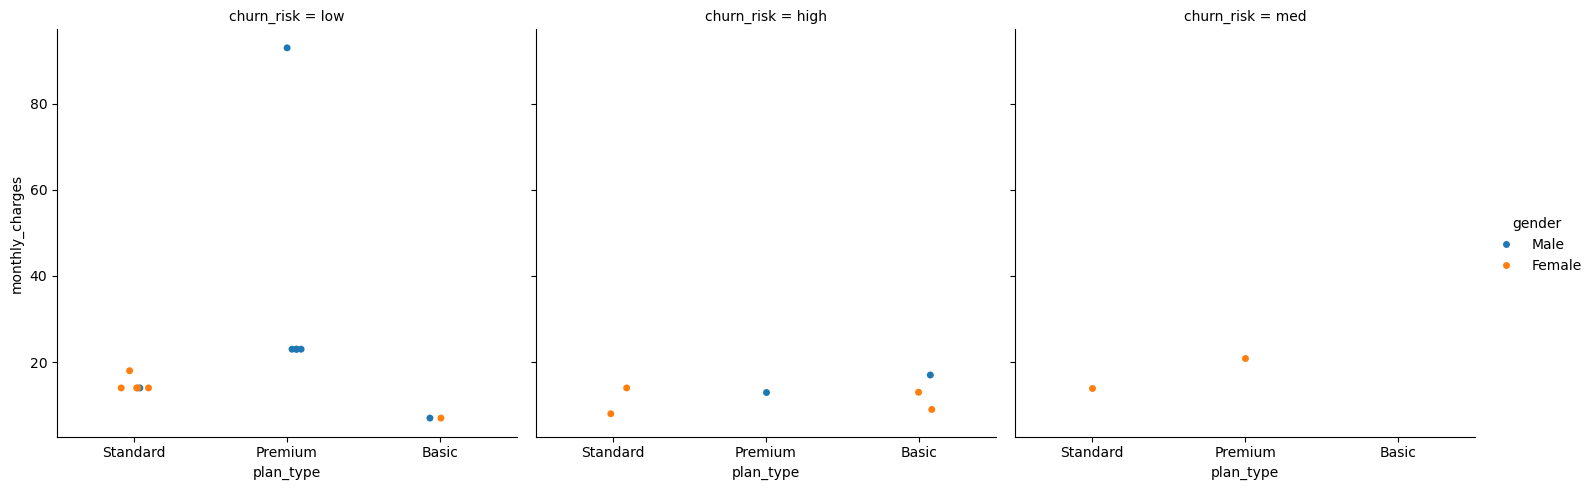

In [134]:
# catplt/ Facegrid Plot - Multi Dimension Comparison

sns.catplot(data= df_visual,
           x = 'plan_type',
           y = 'monthly_charges',
           hue = 'gender',
           col = 'churn_risk')

In [136]:
# Pivot table

pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [137]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values = ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [142]:
# Working With SQL in Python (pandas)
# create db in SQL

conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# Commit and save
conn.commit()

OperationalError: table users already exists

In [145]:
# Insert Details
cursor = conn.cursor()

# Write SQL Query to Insert records in SQL Table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Raghav', 'India', 10000),
            ('Rishabh', 'Germany',20000),
            ('Madhav', 'USA', 30000),
            ('Radha', 'India', 40000),
            ('Shyam', 'India', 50000),
            ('Vishnu', 'France', 20000),
            ('Vishakha', 'India', 40000),
            ('Govind', 'France', 30000),
            ('Hari', 'India', 50000),
            ('Raj', 'Germany', 20000),
            ('Jaya', 'India', 10000),
            ('Abhi', 'Germany', 30000)
    """
)
            
# Commit and save
conn.commit()

In [146]:
# Check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Raghav,India,10000
1,Rishabh,Germany,20000
2,Madhav,USA,30000
3,Radha,India,40000
4,Shyam,India,50000


In [148]:
# Aggregation
query = """
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,France,100000
1,Germany,140000
2,India,400000
3,USA,60000


In [149]:
# Always Close the conn with db once the task is over

conn.close()